# PCA on Gene Expression Data (GSE5325)

Reproducing Figure 1a and Figure 1c from the Nature Primer (2008).  
- **Figure 1a**: Scatter plot of XBP1 vs GATA3 expression across 105 breast cancer patients, coloured by ER subtype.  
- **Figure 1c**: Distribution of patient samples projected onto PC1.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA

## Step 1 — Load the datasets

In [10]:
# Class labels: 1 = ER+, 0 = ER-
y = pd.read_csv('data/class.tsv', sep='\t', header=None, names=['label'])

# Gene ID → symbol mapping
# comment='#' skips the metadata header lines
gene_map = pd.read_csv('data/columns.tsv.gz', sep='\t', comment='#')

# Full gene expression matrix (105 patients × 16 174 genes)
X_all = pd.read_csv('data/filtered.tsv.gz', sep='\t')

# FIX: column names are stored with leading whitespace in the TSV — strip them
X_all.columns = X_all.columns.str.strip()

print(f"Patients : {X_all.shape[0]}")
print(f"Genes    : {X_all.shape[1]}")
print(f"ER+      : {(y['label'] == 1).sum()}  |  ER- : {(y['label'] == 0).sum()}")

Patients : 105
Genes    : 16174
ER+      : 45  |  ER- : 60


## Step 2 — Extract XBP1 and GATA3 expression

In [11]:
# Look up the numeric probe IDs for the two genes of interest
xbp1_id  = str(gene_map.loc[gene_map['GeneSymbol'] == 'XBP1',  'ID'].values[0])  # → 4404
gata3_id = str(gene_map.loc[gene_map['GeneSymbol'] == 'GATA3', 'ID'].values[0])  # → 4359

print(f"XBP1 probe ID : {xbp1_id}  |  GATA3 probe ID : {gata3_id}")

# Slice out only those two columns
X_subset = X_all[[xbp1_id, gata3_id]].copy()
X_subset.columns = ['XBP1', 'GATA3']
X_subset['label'] = y['label'].values

X_subset.head()

XBP1 probe ID : 4404  |  GATA3 probe ID : 4359


,XBP1,GATA3,label
0,2.7836,2.2544,1
1,-0.3359,-0.7640,0
2,-1.0298,2.2355,0
3,2.6186,3.1732,1
4,2.5230,2.7418,1


## Step 3 — Figure 1a: GATA3 vs XBP1 scatter plot

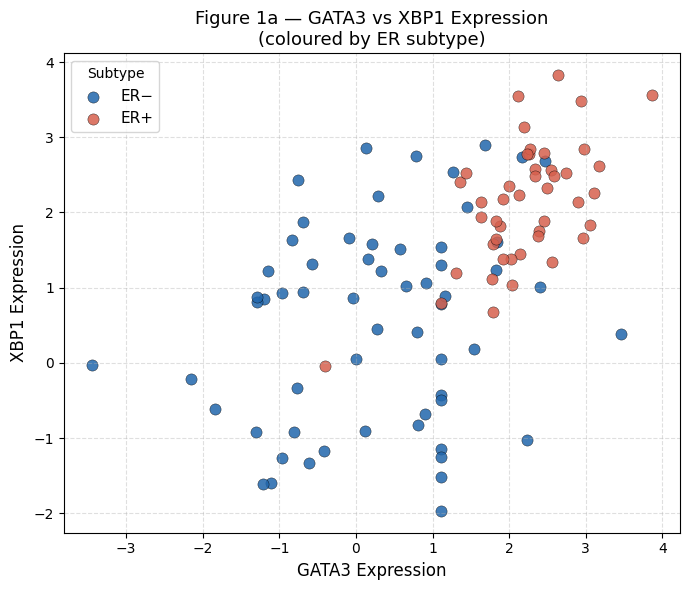

In [12]:
COLORS = {0: '#2166ac', 1: '#d6604d'}   # blue = ER-, red/orange = ER+
LABELS = {0: 'ER−', 1: 'ER+'}

fig, ax = plt.subplots(figsize=(7, 6))

for lbl, grp in X_subset.groupby('label'):
    ax.scatter(
        grp['GATA3'], grp['XBP1'],
        c=COLORS[lbl], label=LABELS[lbl],
        alpha=0.85, s=65, edgecolors='k', linewidths=0.3
    )

ax.set_xlabel('GATA3 Expression', fontsize=12)
ax.set_ylabel('XBP1 Expression',  fontsize=12)
ax.set_title('Figure 1a — GATA3 vs XBP1 Expression\n(coloured by ER subtype)', fontsize=13)
ax.legend(title='Subtype', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Step 4 — PCA: project onto PC1

In [13]:
features = X_subset[['XBP1', 'GATA3']].values

pca = PCA(n_components=1)
pc1_scores = pca.fit_transform(features).flatten()

X_subset = X_subset.copy()          # avoid SettingWithCopyWarning
X_subset['PC1'] = pc1_scores

print(f"Variance explained by PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC1 direction (loadings)  : XBP1={pca.components_[0,0]:.3f},  GATA3={pca.components_[0,1]:.3f}")

Variance explained by PC1 : 77.9%
PC1 direction (loadings)  : XBP1=0.678,  GATA3=0.735


## Step 5 — Figure 1c: distribution along PC1

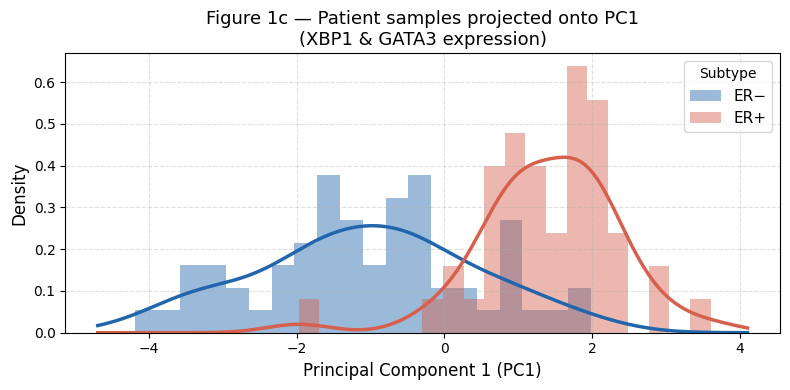

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

x_grid = np.linspace(X_subset['PC1'].min() - 0.5,
                     X_subset['PC1'].max() + 0.5, 300)

for lbl, grp in X_subset.groupby('label'):
    ax.hist(
        grp['PC1'], bins=20,
        color=COLORS[lbl], alpha=0.45,
        density=True, label=LABELS[lbl]
    )
    kde = gaussian_kde(grp['PC1'])
    ax.plot(x_grid, kde(x_grid), color=COLORS[lbl], lw=2.5)

ax.set_xlabel('Principal Component 1 (PC1)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Figure 1c — Patient samples projected onto PC1\n(XBP1 & GATA3 expression)', fontsize=13)
ax.legend(title='Subtype', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## PCA plot using PC1

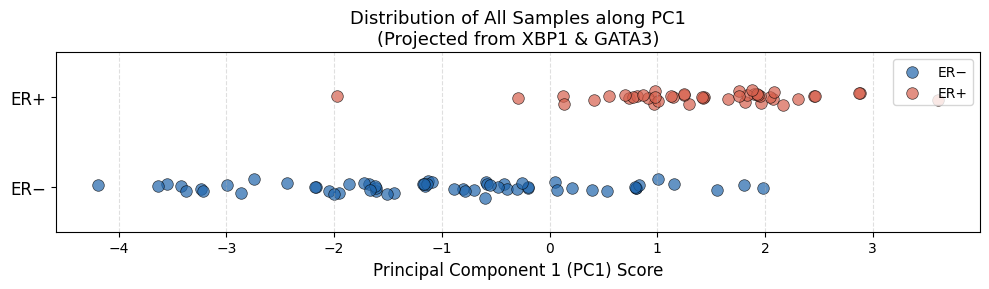

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming X_subset already contains the 'PC1' column from the PCA transform
fig, ax = plt.subplots(figsize=(10, 3))

# Plot each group with a slight vertical jitter to make individual points visible
for lbl, grp in X_subset.groupby('label'):
    # Generate random jitter for the Y-axis to spread out overlapping points
    jitter = np.random.normal(0, 0.04, size=len(grp))
    
    ax.scatter(
        grp['PC1'], 
        np.full(len(grp), lbl) + jitter, 
        c=COLORS[lbl], 
        label=LABELS[lbl],
        alpha=0.7, 
        edgecolors='k', 
        linewidths=0.5,
        s=70
    )

# Formatting the 1D axis
ax.set_yticks([0, 1])
ax.set_yticklabels([LABELS[0], LABELS[1]], fontsize=12)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('Principal Component 1 (PC1) Score', fontsize=12)
ax.set_title('Distribution of All Samples along PC1\n(Projected from XBP1 & GATA3)', fontsize=13)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('pc1_strip_plot.png')
plt.show()